LLM agents refer to software entities designed to perform tasks autonomously or semi-autonomously using the capabilities of the LLM. An agent processes a user's request given in natural language, which might be ambiguous and complex. The agent then decomposes the request into specific tasks and assigns these tasks to the appropriate tools.

### LangChain Agents

LangChain Agents use language models to interact with other tools and are designed to perform well-designed tasks. They can be used for tasks such as question/answer, interfacing with APIs, generating text, generating images, language translation, summarizing text, etc.

Some examples of LangChain Agents are:

- CSV Agent
- Pandas DataFrame Agent
- Python Agent
- JSON Agent
- Spark DataFrame Agent
- Xorbits Agent
- SQL Agent


In [1]:
conda env list


# conda environments:
#
base                   /opt/anaconda3
HuggingFaceBook      * /opt/anaconda3/envs/HuggingFaceBook
islp                   /opt/anaconda3/envs/islp
langsmith              /opt/anaconda3/envs/langsmith
llm-from-scratch       /opt/anaconda3/envs/llm-from-scratch
llms                   /opt/anaconda3/envs/llms
py313                  /opt/anaconda3/envs/py313
python-ds-ml-bootcamp   /opt/anaconda3/envs/python-ds-ml-bootcamp


Note: you may need to restart the kernel to use updated packages.


In [7]:
# !pip install langchain
# !pip install langchain_experimental
# !pip install tabulate
# !pip install langchain_openai

In [2]:
import os
import jk_secrets
os.environ['OPENAI_API_KEY'] = jk_secrets.OPENAI_API_KEY

In [3]:
# 7.1
from langchain_experimental.agents.agent_toolkits import \
    create_python_agent
from langchain_experimental.tools.python.tool import PythonREPLTool
from langchain_openai.chat_models import ChatOpenAI
 
python_tool = PythonREPLTool()
agent = create_python_agent(
    llm = ChatOpenAI(temperature = 0, 
                     model = 
                        "gpt-4.1"),
                     # "gpt-4"),
    verbose = True,
    handle_parsing_errors = True,
    tool = python_tool
)

The PythonREPLTool is a tool within the LangChain library that allows an agent to execute Python code dynamically. This tool is particularly useful for scenarios where you need to run arbitrary Python code as part of your agent's workflow, enabling complex computations, data manipulations, and integrations with other Python libraries and functionalities.

In [19]:
from openai import OpenAI
 
client = OpenAI(api_key = os.getenv('OPENAI_API_KEY')) 
models = client.models.list()
# [model.id for model in models.data]. # long list of all the models

In [20]:
# agent.invoke('''
# Create a function to generate the Fibonacci sequence.
# ''')

In [26]:
agent.invoke('''
Create a Python function to rename each JPG or JPEG image found in a 'start' directory.
If the file extension is '.jpeg', it should be changed to '.jpg'.  The file extension should be lowercase.
Append to the filename a period and the pixel dimensions of the image.   
The pixel dimensions should be expressed as width by height.
For example, a file named 'test.1234.jpg' with a dimension of 3024 pixels by 4032 pixels 
should be renamed 'test.1234.3024x4032.jpg'.
Put the renamed image file in a 'renamed' directory.
''')



> Entering new AgentExecutor chain...
Thought: I need to write a function that will:
1. Iterate through all files in the 'start' directory.
2. For each file, check if it is a JPG or JPEG image (case-insensitive).
3. Open the image to get its dimensions.
4. Rename the file according to the rules (extension to .jpg, append .WIDTHxHEIGHT).
5. Save the renamed file in the 'renamed' directory.

I'll use os, shutil, and PIL (Pillow) for this task.

Action: I'll write the function and print it out.

Action Input: 
```python
import os
from PIL import Image
import shutil

def rename_images(start_dir, renamed_dir):
    if not os.path.exists(renamed_dir):
        os.makedirs(renamed_dir)
    for filename in os.listdir(start_dir):
        file_lower = filename.lower()
        if file_lower.endswith('.jpg') or file_lower.endswith('.jpeg'):
            name, ext = os.path.splitext(filename)
            ext = '.jpg'  # always use .jpg
            img_path = os.path.join(start_dir, filename)
       

{'input': "\nCreate a Python function to rename each JPG or JPEG image found in a 'start' directory.\nIf the file extension is '.jpeg', it should be changed to '.jpg'.  The file extension should be lowercase.\nAppend to the filename a period and the pixel dimensions of the image.   \nThe pixel dimensions should be expressed as width by height.\nFor example, a file named 'test.1234.jpg' with a dimension of 3024 pixels by 4032 pixels \nshould be renamed 'test.1234.3024x4032.jpg'.\nPut the renamed image file in a 'renamed' directory.\n",
 'output': '```python\nimport os\nfrom PIL import Image\nimport shutil\n\ndef rename_images(start_dir, renamed_dir):\n    if not os.path.exists(renamed_dir):\n        os.makedirs(renamed_dir)\n    for filename in os.listdir(start_dir):\n        file_lower = filename.lower()\n        if file_lower.endswith(\'.jpg\') or file_lower.endswith(\'.jpeg\'):\n            name, ext = os.path.splitext(filename)\n            ext = \'.jpg\'  # always use .jpg\n       

In [32]:
# a function that will:
# 1. Iterate through all files in the 'start' directory.
# 2. For each file, check if it is a JPG or JPEG image (case-insensitive).
# 3. Open the image to get its dimensions.
# 4. Rename the file according to the rules (extension to .jpg, append .WIDTHxHEIGHT).
# 5. Save the renamed file in the 'renamed' directory.

import os
from PIL import Image
import shutil

def rename_images(start_dir, renamed_dir):
    if not os.path.exists(renamed_dir):
        os.makedirs(renamed_dir)
    for filename in os.listdir(start_dir):
        file_lower = filename.lower()
        if file_lower.endswith('.jpg') or file_lower.endswith('.jpeg'):
            name, ext = os.path.splitext(filename)
            ext = '.jpg'  # always use .jpg
            img_path = os.path.join(start_dir, filename)
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
            except Exception as e:
                print(f"Could not open {filename}: {e}")
                continue
            new_name = f"{name}.{width}x{height}{ext}"
            new_path = os.path.join(renamed_dir, new_name)
            shutil.copy2(img_path, new_path)

start='/Users/blauerbock/workspaces/react-photo-album-main/examples/react-lightbox-photo-album/photos/start/'
renamed='/Users/blauerbock/workspaces/react-photo-album-main/examples/react-lightbox-photo-album/photos/renamed/'
rename_images(start, renamed) 


In [21]:
agent.invoke('''
Create a Python function to create different copies of each JPG image file found in a 'start' directory.   
For each JPG image file in the 'start' directory, create copies having an image dimension width in pixels 
of 1080, 640, 384, 256, 128, 96, 64, and 48.  
Save the copies in a 'destination' directory.
Append a period and the new width dimension plus the letter 'w' to the filename when saving the copy.
For example, for an original file named 'test.4430.jpg', the name of the copy 
having a width of 1080 pixels would be 'test.4430.1080w.jpg'.
''')



> Entering new AgentExecutor chain...
Thought: I need to write a Python function that:
1. Iterates through all JPG files in a 'start' directory.
2. For each file, resizes it to each of the specified widths, maintaining aspect ratio.
3. Saves each resized image in a 'destination' directory, with the new filename format.

I'll use the `os` and `PIL` (Pillow) libraries for file and image operations.

Action: I'll write the function as described and print it out.

Action Input: 
```python
import os
from PIL import Image

def create_resized_copies(start_dir, dest_dir):
    widths = [1080, 640, 384, 256, 128, 96, 64, 48]
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)
    for filename in os.listdir(start_dir):
        if filename.lower().endswith('.jpg'):
            filepath = os.path.join(start_dir, filename)
            with Image.open(filepath) as img:
                for w in widths:
                    # Calculate new height to maintain aspect ratio
               

{'input': "\nCreate a Python function to create different copies of each JPG image file found in a 'start' directory.   \nFor each JPG image file in the 'start' directory, create copies having an image dimension width in pixels \nof 1080, 640, 384, 256, 128, 96, 64, and 48.  \nSave the copies in a 'destination' directory.\nAppend a period and the new width dimension plus the letter 'w' to the filename when saving the copy.\nFor example, for an original file named 'test.4430.jpg', the name of the copy \nhaving a width of 1080 pixels would be 'test.4430.1080w.jpg'.\n",
 'output': '```python\nimport os\nfrom PIL import Image\n\ndef create_resized_copies(start_dir, dest_dir):\n    widths = [1080, 640, 384, 256, 128, 96, 64, 48]\n    if not os.path.exists(dest_dir):\n        os.makedirs(dest_dir)\n    for filename in os.listdir(start_dir):\n        if filename.lower().endswith(\'.jpg\'):\n            filepath = os.path.join(start_dir, filename)\n            with Image.open(filepath) as img:

In [33]:
import os
from PIL import Image

def create_resized_copies(start_dir, dest_dir):
    widths = [1080, 640, 384, 256, 128, 96, 64, 48]
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)
    for filename in os.listdir(start_dir):
        if filename.lower().endswith('.jpg'):
            filepath = os.path.join(start_dir, filename)
            with Image.open(filepath) as img:
                for w in widths:
                    # Calculate new height to maintain aspect ratio
                    aspect_ratio = img.height / img.width
                    new_height = int(w * aspect_ratio)
                    resized_img = img.resize((w, new_height), Image.LANCZOS)
                    # Build new filename
                    name, ext = os.path.splitext(filename)
                    new_filename = f"{name}.{w}w{ext}"
                    dest_path = os.path.join(dest_dir, new_filename)
                    resized_img.save(dest_path, "JPEG")

start='/Users/blauerbock/workspaces/react-photo-album-main/examples/react-lightbox-photo-album/photos/renamed/'
dest='/Users/blauerbock/workspaces/react-photo-album-main/examples/react-lightbox-photo-album/photos/dest/'
create_resized_copies(start, dest) 
                    
# This function will create resized copies of each JPG image in the 'start' directory, saving 
#                     them in the 'destination' directory with the specified filename format.

In [34]:
agent.invoke('''
Create a Python function to copy and rename any JPG image file found in a 'renamed' directory 
and put the renamed image file in a 'destination' directory.
Append to the filename a period and the pixel width of the image plus 'w'.
For example, a file named 'crime-scene.3333.3024x4032.jpg' having a dimension of 3024 pixels wide 
should be renamed 'crime-scene.3333.3024x4032.3024w.jpg'
Save the copies in a 'destination' directory.
''')



> Entering new AgentExecutor chain...
Thought: I need to write a Python function that will:
1. Search for JPG files in the 'renamed' directory.
2. For each file, open it, get its width in pixels.
3. Rename the file by appending ".{width}w" before the ".jpg" extension.
4. Copy the renamed file to the 'destination' directory.

I'll use the os, shutil, and PIL (Pillow) libraries for this task.

Action: I'll write the function and print it out.

Action Input: 
```python
import os
import shutil
from PIL import Image

def copy_and_rename_jpg_images():
    src_dir = 'renamed'
    dst_dir = 'destination'
    if not os.path.exists(dst_dir):
        os.makedirs(dst_dir)
    for filename in os.listdir(src_dir):
        if filename.lower().endswith('.jpg'):
            src_path = os.path.join(src_dir, filename)
            try:
                with Image.open(src_path) as img:
                    width, _ = img.size
            except Exception as e:
                print(f"Error opening {filena

{'input': "\nCreate a Python function to copy and rename any JPG image file found in a 'renamed' directory \nand put the renamed image file in a 'destination' directory.\nAppend to the filename a period and the pixel width of the image plus 'w'.\nFor example, a file named 'crime-scene.3333.3024x4032.jpg' having a dimension of 3024 pixels wide \nshould be renamed 'crime-scene.3333.3024x4032.3024w.jpg'\nSave the copies in a 'destination' directory.\n",
 'output': '```python\nimport os\nimport shutil\nfrom PIL import Image\n\ndef copy_and_rename_jpg_images():\n    src_dir = \'renamed\'\n    dst_dir = \'destination\'\n    if not os.path.exists(dst_dir):\n        os.makedirs(dst_dir)\n    for filename in os.listdir(src_dir):\n        if filename.lower().endswith(\'.jpg\'):\n            src_path = os.path.join(src_dir, filename)\n            try:\n                with Image.open(src_path) as img:\n                    width, _ = img.size\n            except Exception as e:\n                pr

In [36]:
import os
import shutil
from PIL import Image

def copy_and_rename_jpg_images(src_dir, dst_dir):
    # src_dir = 'renamed'
    # dst_dir = 'destination'
    if not os.path.exists(dst_dir):
        os.makedirs(dst_dir)
    for filename in os.listdir(src_dir):
        if filename.lower().endswith('.jpg'):
            src_path = os.path.join(src_dir, filename)
            try:
                with Image.open(src_path) as img:
                    width, _ = img.size
            except Exception as e:
                print(f"Error opening {filename}: {e}")
                continue
            name, ext = os.path.splitext(filename)
            new_filename = f"{name}.{width}w{ext}"
            dst_path = os.path.join(dst_dir, new_filename)
            shutil.copy2(src_path, dst_path)
            print(f"Copied and renamed: {src_path} -> {dst_path}")


renamed='/Users/blauerbock/workspaces/react-photo-album-main/examples/react-lightbox-photo-album/photos/renamed/'
dest='/Users/blauerbock/workspaces/react-photo-album-main/examples/react-lightbox-photo-album/photos/dest/'
copy_and_rename_jpg_images(renamed, dest)

Copied and renamed: /Users/blauerbock/workspaces/react-photo-album-main/examples/react-lightbox-photo-album/photos/renamed/Engelhartszell_an_der_Donau_Innviertel_Austria.1000.4032x3024.jpg -> /Users/blauerbock/workspaces/react-photo-album-main/examples/react-lightbox-photo-album/photos/dest/Engelhartszell_an_der_Donau_Innviertel_Austria.1000.4032x3024.4032w.jpg
Copied and renamed: /Users/blauerbock/workspaces/react-photo-album-main/examples/react-lightbox-photo-album/photos/renamed/bronze.3623.1493x1613.jpg -> /Users/blauerbock/workspaces/react-photo-album-main/examples/react-lightbox-photo-album/photos/dest/bronze.3623.1493x1613.1493w.jpg


In [19]:
# agent execute code
agent.invoke('''
fibonacci = lambda n, a=0, b=1: a if n == 0 else fibonacci(n - 1, b, a + b)
result = [fibonacci(x) for x in range(10)]
''')



> Entering new AgentExecutor chain...
Action: Python_REPL
Action Input: fibonacci = lambda n, a=0, b=1: a if n == 0 else fibonacci(n - 1, b, a + b)
result = [fibonacci(x) for x in range(10)]
print(result)
Observation: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]

I now know the final answer
Final Answer: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]

> Finished chain.


{'input': '\nfibonacci = lambda n, a=0, b=1: a if n == 0 else fibonacci(n - 1, b, a + b)\nresult = [fibonacci(x) for x in range(10)]\n',
 'output': '[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]'}

In [20]:
agent.invoke('''
I have a dataFrame 'df' with columns 'Age' and 'height'. 
Write the code to find the correlation between the two columns, but don't execute it.
'''
)



> Entering new AgentExecutor chain...
To answer this, I need to write the code that calculates the correlation between the 'Age' and 'height' columns in the DataFrame 'df', but I should not execute it.

Final Answer: 
df['Age'].corr(df['height'])

> Finished chain.


{'input': "\nI have a dataFrame 'df' with columns 'Age' and 'height'. \nWrite the code to find the correlation between the two columns, but don't execute it.\n",
 'output': "df['Age'].corr(df['height'])"}

In [21]:
ls

__pycache__/
acronyms-defs.md
archives/
behavioral_economics_puzzles.md
Ch_05_Exploring_Tokenizing_and_Visualizing_HF_Datasets.ipynb
Ch_06_Fine_Tuning_Pretrained_Models_Multimodal_Models.ipynb
Ch_08_Creating_LLM-based_Apps_Using_LangChain_and_LlamaIndex.ipynb
Ch_7_Agents.ipynb
Chapter_02_Getting_Started.ipynb
Chapter_03_Using_HF_Transformers_and_Pipelines_for_NLP_Tasks.ipynb
Chapter_04_Using_HF_for_Computer_Vision_Tasks.ipynb
default__vector_store.json
docstore-2.json
docstore.json
fib-agent.py
graph_store.json
image__vector_store.json
images/
index_store.json
jk_prompts.py
jk_secrets.py
LangChain-Ollama.ipynb
Langsmith.ipynb
light-face/
object_detection.py
object_detection2.py
README.md
results/
softmax-with-torch.py
softmax.py
softmax.xlsx
training_documents/
vocab-tab-delimited.txt
vocab-tab-delimited.xlsx
vocab.txt
webcam.py
webserver/


In [22]:
import pandas as pd
 
df = pd.read_csv('titanic_train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [23]:
import os
import jk_secrets
os.environ['OPENAI_API_KEY'] = jk_secrets.OPENAI_API_KEY

In [24]:
from langchain_experimental.agents.agent_toolkits \
    import create_pandas_dataframe_agent
from langchain.llms import OpenAI

In [25]:
pd_agent = create_pandas_dataframe_agent(
    llm = ChatOpenAI(temperature = 0, model = "gpt-4.1"),
    df = df, 
    verbose = True,
    allow_dangerous_code = True)

In [26]:
pd_agent.invoke("What percentage of passengers survived?")



> Entering new AgentExecutor chain...
Thought: To find the percentage of passengers who survived, I need to calculate the mean of the 'Survived' column (since it is 1 for survived, 0 for not), and multiply by 100.
Action: python_repl_ast
I now know the final answer038.38383838383838
Final Answer: 38.38% of passengers survived.

> Finished chain.


{'input': 'What percentage of passengers survived?',
 'output': '38.38% of passengers survived.'}

In [29]:
df['Survived'].mean()

0.3838383838383838

In [30]:
pd_agent.invoke('''
Count the number of male passengers who survived.
''')



> Entering new AgentExecutor chain...
Thought: To answer this, I need to filter the dataframe for rows where 'Sex' is 'male' and 'Survived' is 1, then count the number of such rows.
Action: python_repl_ast
I now know the final answer (df['Survived'] == 1)].shape[0]109
Final Answer: 109 male passengers survived.

> Finished chain.


{'input': '\nCount the number of male passengers who survived.\n',
 'output': '109 male passengers survived.'}

In [ ]:
print(df.shape)
df[(df['Sex'] == 'male')][(df['Survived'] == 1)]

In [45]:
print(df.shape)
df[(df['Sex'] == 'male')][(df['Survived'] == 1)]

(891, 12)


/var/folders/mm/h2z28vhs6cdbnsksl2fzl19w0000gn/T/ipykernel_37299/3827913549.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[(df['Sex'] == 'male')][(df['Survived'] == 1)]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
36,37,1,3,"Mamee, Mr. Hanna",male,NaN,0,0,2677,7.2292,NaN,C
55,56,1,1,"Woolner, Mr. Hugh",male,NaN,0,0,19947,35.5000,C52,S
...,...,...,...,...,...,...,...,...,...,...,...,...
838,839,1,3,"Chip, Mr. Chang",male,32.0,0,0,1601,56.4958,NaN,S
839,840,1,1,"Marechal, Mr. Pierre",male,NaN,0,0,11774,29.7000,C47,C
857,858,1,1,"Daly, Mr. Peter Denis",male,51.0,0,0,113055,26.5500,E17,S
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S


### 7.2.3 CSV Agent

In [1]:
from langchain_experimental.agents.agent_toolkits import create_csv_agent
from langchain_community.chat_models import ChatOpenAI

import os
import jk_secrets
os.environ['OPENAI_API_KEY'] = jk_secrets.OPENAI_API_KEY

csv_agent = create_csv_agent(
    llm = ChatOpenAI(temperature = 0, model = "gpt-4.1"),    
    path = "titanic_train.csv",
    verbose = True,
    allow_dangerous_code = True)
 
csv_agent.invoke('''
Split the name based on Title. and return the unique list 
of titles in the name.
''')

/var/folders/mm/h2z28vhs6cdbnsksl2fzl19w0000gn/T/ipykernel_43300/2959083737.py:9: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(temperature = 0, model = "gpt-4.1"),




> Entering new AgentExecutor chain...
Thought: To get the unique list of titles, I need to extract the substring between the comma and the period in the "Name" column, then get the unique values.
Action: python_repl_ast
Action Input: df['Name'].str.extract(r',\s*([^\.]+)\.')[0].unique()['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
I now know the final answer' 'Jonkheer']
Final Answer: The unique list of titles in the "Name" column is: ['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms', 'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess', 'Jonkheer']

> Finished chain.


{'input': '\nSplit the name based on Title. and return the unique list \nof titles in the name.\n',
 'output': 'The unique list of titles in the "Name" column is: [\'Mr\', \'Mrs\', \'Miss\', \'Master\', \'Don\', \'Rev\', \'Dr\', \'Mme\', \'Ms\', \'Major\', \'Lady\', \'Sir\', \'Mlle\', \'Col\', \'Capt\', \'the Countess\', \'Jonkheer\']'}



> Entering new AgentExecutor chain...
Thought: To plot the age distribution, I should use matplotlib or seaborn to create a histogram of the 'Age' column in the dataframe. First, I will check if there are any missing values in the 'Age' column, and then plot the histogram.
Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt; df['Age'].hist(bins=20); plt.xlabel('Age'); plt.ylabel('Count'); plt.title('Age Distribution'); plt.show()

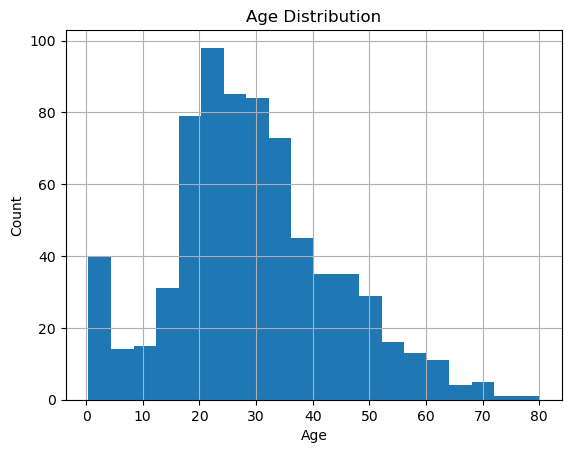

Thought: The histogram of the 'Age' column has been plotted, showing the distribution of ages among the passengers in the dataframe.
Final Answer: The age distribution chart has been plotted using a histogram of the 'Age' column in the dataframe.

> Finished chain.
{'input': 'Plot a chart showing age distribution', 'output': "The age distribution chart has been plotted using a histogram of the 'Age' column in the dataframe."}


In [2]:
response = csv_agent.invoke("Plot a chart showing age distribution")
print(response)



> Entering new AgentExecutor chain...
Thought: To plot a pie chart showing embarkation, I need to count the number of passengers for each value in the 'Embarked' column and then plot these counts as a pie chart.
Action: python_repl_ast
Thought: The pie chart has been successfully created, showing the distribution of passengers by their embarkation port. The chart displays the proportion of passengers who embarked from each port (S, C, Q) as a percentage of the total.
Final Answer: The pie chart showing embarkation has been plotted, displaying the distribution of passengers by their embarkation port.

> Finished chain.


{'input': 'Plot a pie chart showing embarkation',
 'output': 'The pie chart showing embarkation has been plotted, displaying the distribution of passengers by their embarkation port.'}

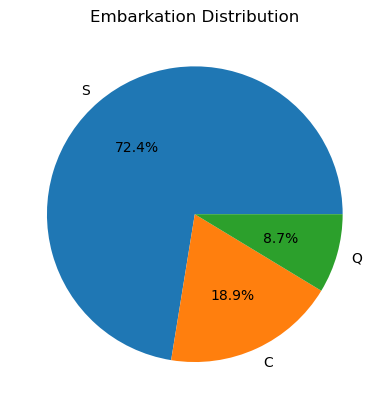

In [3]:
csv_agent.invoke("Plot a pie chart showing embarkation")

### JSON Agent

In [5]:
import json
from langchain_openai import ChatOpenAI
from langchain.agents import create_json_agent
from langchain_community.tools.json.tool import JsonSpec
from langchain_community.agent_toolkits import JsonToolkit
 
with open("speakers.json") as f:
    data = json.load(f)
json_spec = JsonSpec(dict_ = data, max_value_length = 10000)
json_toolkit = JsonToolkit(spec = json_spec)
 
json_agent = create_json_agent(
    llm = ChatOpenAI(temperature = 0, model = "gpt-4"),    
    toolkit=json_toolkit, 
    verbose=True
)

In [6]:
json_agent.invoke(
    "How many speakers are there?"
)



> Entering new AgentExecutor chain...
Action: json_spec_list_keys
Action Input: data
Observation: ['speakers']
The 'speakers' key might contain the information about the number of speakers. I should check the value of this key.
Action: json_spec_get_value
Action Input: data["speakers"]
Observation: [{'name': 'Mr Bellingham', 'shortname': 'Barot_Bellingham', 'reknown': 'Royal Academy of Painting and Sculpture', 'bio': 'Barot has just finished his final year at The Royal Academy...'}, {'name': 'Jonathan G. Ferrar II', 'shortname': 'Jonathan_Ferrar', 'reknown': 'Artist to Watch in 2012', 'bio': 'The Artist to Watch in 2012 by the London Review,...'}, {'name': 'Hillary Hewitt Goldwynn-Post', 'shortname': 'Hillary_Goldwynn', 'reknown': 'New York University', 'bio': 'Hillary is a sophomore art sculpture student at New York...'}, {'name': 'Hassum Harrod', 'shortname': 'Hassum_Harrod', 'reknown': 'Art College in New Dehli', 'bio': 'The Art College in New Dehli has sponsored Hassum on...'}, {

{'input': 'How many speakers are there?', 'output': 'There are 9 speakers.'}

In [7]:
json_agent.run(
    "Show me the list of speakers"
)

/var/folders/mm/h2z28vhs6cdbnsksl2fzl19w0000gn/T/ipykernel_43300/414485291.py:1: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  json_agent.run(




> Entering new AgentExecutor chain...
Action: json_spec_list_keys
Action Input: data
Observation: ['speakers']
The 'speakers' key might contain the information I need. I should check the value of this key.
Action: json_spec_get_value
Action Input: data["speakers"]
Observation: [{'name': 'Mr Bellingham', 'shortname': 'Barot_Bellingham', 'reknown': 'Royal Academy of Painting and Sculpture', 'bio': 'Barot has just finished his final year at The Royal Academy...'}, {'name': 'Jonathan G. Ferrar II', 'shortname': 'Jonathan_Ferrar', 'reknown': 'Artist to Watch in 2012', 'bio': 'The Artist to Watch in 2012 by the London Review,...'}, {'name': 'Hillary Hewitt Goldwynn-Post', 'shortname': 'Hillary_Goldwynn', 'reknown': 'New York University', 'bio': 'Hillary is a sophomore art sculpture student at New York...'}, {'name': 'Hassum Harrod', 'shortname': 'Hassum_Harrod', 'reknown': 'Art College in New Dehli', 'bio': 'The Art College in New Dehli has sponsored Hassum on...'}, {'name': 'Jennifer Jero

'The list of speakers is: \n1. Mr Bellingham\n2. Jonathan G. Ferrar II\n3. Hillary Hewitt Goldwynn-Post\n4. Hassum Harrod\n5. Jennifer Jerome\n6. LaVonne L. LaRue\n7. Constance Olivia Smith\n8. Riley Rudolph Rewington\n9. Xhou Ta'

In [8]:
json_agent.run(
    "Based on the bio, who was a student at New York University"
)



> Entering new AgentExecutor chain...
Action: json_spec_list_keys
Action Input: data
Observation: ['speakers']
The 'speakers' key might contain information about the bio of the speakers. I should explore this key.
Action: json_spec_list_keys
Action Input: data["speakers"]
Observation: ValueError('Value at path `data["speakers"]` is not a dict, get the value directly.')
The 'speakers' key is not a dictionary, so I should get its value directly.
Action: json_spec_get_value
Action Input: data["speakers"]
Observation: [{'name': 'Mr Bellingham', 'shortname': 'Barot_Bellingham', 'reknown': 'Royal Academy of Painting and Sculpture', 'bio': 'Barot has just finished his final year at The Royal Academy...'}, {'name': 'Jonathan G. Ferrar II', 'shortname': 'Jonathan_Ferrar', 'reknown': 'Artist to Watch in 2012', 'bio': 'The Artist to Watch in 2012 by the London Review,...'}, {'name': 'Hillary Hewitt Goldwynn-Post', 'shortname': 'Hillary_Goldwynn', 'reknown': 'New York University', 'bio': 'Hillar

'Hillary Hewitt Goldwynn-Post was a student at New York University.'

In [10]:
from langchain_experimental.agents.agent_toolkits import create_csv_agent
from langchain_community.chat_models import ChatOpenAI
from langchain.agents.agent_types import AgentType

csv_agent = create_csv_agent(
    llm = ChatOpenAI(temperature = 0, model = "gpt-4"),    
    path = "titanic_train.csv",
    verbose = True,
    allow_dangerous_code = True,
    agent_type = AgentType.ZERO_SHOT_REACT_DESCRIPTION,  # default
)

In [11]:
csv_agent = create_csv_agent(
    llm = ChatOpenAI(temperature = 0, model = "gpt-4"),    
    path = "titanic_train.csv",
    verbose = True,
    allow_dangerous_code = True,
    agent_type = AgentType.ZERO_SHOT_REACT_DESCRIPTION,    
)
csv_agent.invoke("Get all first class passengers")




> Entering new AgentExecutor chain...
Thought: To get all first class passengers, I need to filter the dataframe where the 'Pclass' column is equal to 1.
Action: python_repl_ast
Action Input: df[df['Pclass'] == 1]     PassengerId  Survived  Pclass  \
1              2         1       1   
3              4         1       1   
6              7         0       1   
11            12         1       1   
23            24         1       1   
..           ...       ...     ...   
871          872         1       1   
872          873         0       1   
879          880         1       1   
887          888         1       1   
889          890         1       1   

                                                  Name     Sex   Age  SibSp  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
6                              McCarthy, Mr. Timothy J    male  54.0      0   
11          

{'input': 'Get all first class passengers',
 'output': "The first class passengers are those whose records are in the filtered dataframe where the 'Pclass' column is equal to 1. There are 216 such passengers."}

In [13]:
csv_agent = create_csv_agent(
    llm = ChatOpenAI(temperature = 0, model = "gpt-4.1"),    
    path = "titanic_train.csv",
    verbose = True,
    allow_dangerous_code = True,
    agent_type = 'openai-tools',
)

## 7.3 Hugging Face Transformers Agents

Tools are interfaces that an agent can use to interact with. Agents use various tools to perform tasks autonomously. These tools can be anything from simple utilities to complex services that help the agent complete its assigned tasks.

Some examples of tools are:

- PythonREPLTool – a tool in the LangChain framework to allow agents to execute Python code dynamically
- PythonAstREPLTool - a tool in the LangChain framework designed to safely execute Python code by leveraging the Abstract Syntax Tree (AST) module. This approach ensures a higher level of security by parsing and analyzing Python code before execution, reducing the risk of executing harmful or malicious code.
- FinalAnswerTool – a tool within the Transformers library to answer questions based on user’s questions.
- DocumentQuestionAnsweringTool – a tool within the Transformers library to answer questions based on a PDF document
- TranslationTool – a tool within the Transformers library to perform translation on sentences.

In this chapter, we will discuss two types of agents and provide examples of how they work. They are:

- LangChain Agents
- Transformers Agents

Hugging Face Transformers Agents
Besides using the agents from LangChain, Hugging Face also provides its own agents. At the time of writing, you can use the following agents from Hugging Face:
- CodeAgent – generates code to solve the task and then executes the
code

- ReactCodeAgent – solves the problem step by step, and writes the tool, call in Python
- ReactJsonAgent - writes the tool call in JSON
Note that at the time of writing, Transformers Agents is an experimental API which is subject to change at any time. Results returned by the agents can vary as the APIs or underlying models are prone to change